In [ ]:
!pip install -q "scikit-learn==1.5.2" "scikeras==0.13.0"
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, time
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

np.random.seed(42); tf.random.set_seed(42)
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load + explore

X_train: (60000, 28, 28) | y_train: (60000,)
X_test : (10000, 28, 28) | y_test : (10000,)
Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


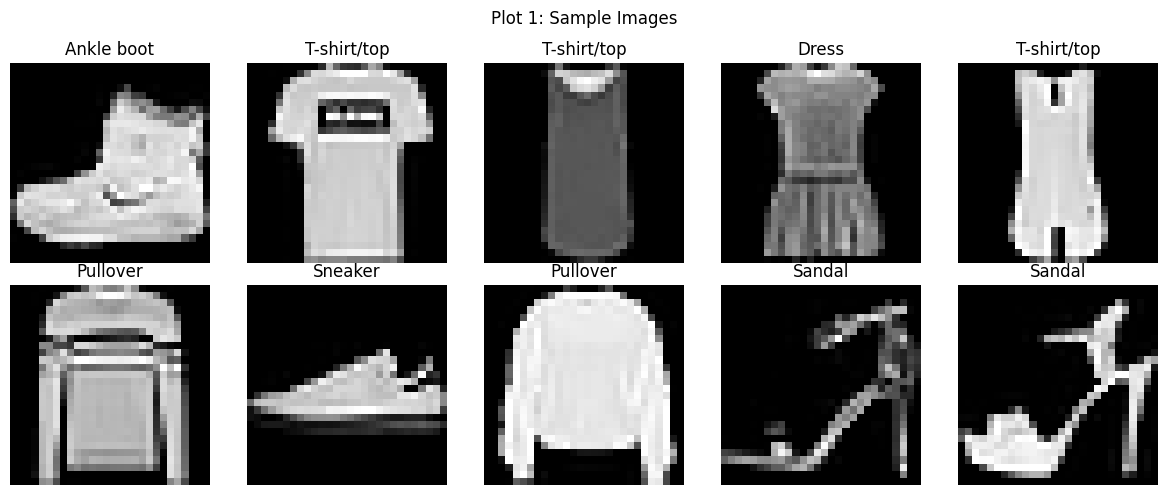

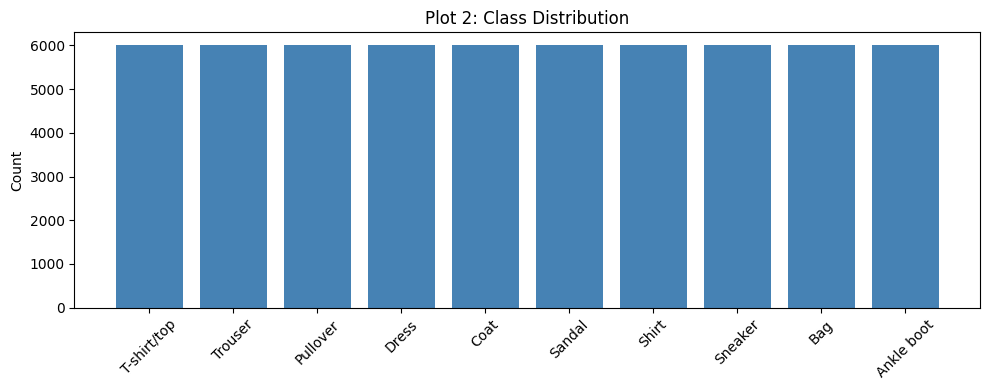

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())
print("Classes:", np.unique(y_train))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]]); ax.axis('off')
plt.suptitle("Plot 1: Sample Images"); plt.tight_layout(); plt.show()

unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10,4))
plt.bar(unique, counts, color='steelblue')
plt.xticks(unique, class_names, rotation=45)
plt.ylabel("Count"); plt.title("Plot 2: Class Distribution")
plt.tight_layout(); plt.show()

PREPROCESSING

In [ ]:
print("BEFORE →", X_train.shape, X_train.dtype, "| labels:", y_train[:5])

X_train_norm = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_norm  = X_test.reshape(-1, 784).astype('float32') / 255.0
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh  = tf.keras.utils.to_categorical(y_test, 10)

print("AFTER  →", X_train_norm.shape, X_train_norm.dtype, "| label[0]:", y_train_oh[0])

BEFORE → (60000, 28, 28) uint8 | labels: [9 0 0 3 0]
AFTER  → (60000, 784) float32 | label[0]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


Baseline model

In [ ]:
baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')
])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train baseline

In [ ]:
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history = baseline.fit(X_train_norm, y_train_oh, epochs=20, batch_size=32,
                       validation_split=0.2, verbose=1)
baseline_time = time.time() - t0
print(f"\nBaseline training time: {baseline_time:.1f}s")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8141 - loss: 0.5160 - val_accuracy: 0.8471 - val_loss: 0.4180
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8624 - loss: 0.3785 - val_accuracy: 0.8591 - val_loss: 0.3817
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8752 - loss: 0.3401 - val_accuracy: 0.8662 - val_loss: 0.3602
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8851 - loss: 0.3131 - val_accuracy: 0.8731 - val_loss: 0.3485
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8913 - loss: 0.2928 - val_accuracy: 0.8783 - val_loss: 0.3430
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8968 - loss: 0.2757 - val_accuracy: 0.8790 - val_loss: 0.3409
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9029 - loss: 0.2615 - val_accuracy: 0.8795 - val_loss: 0.3454
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9058 - loss: 0.2495 

curves

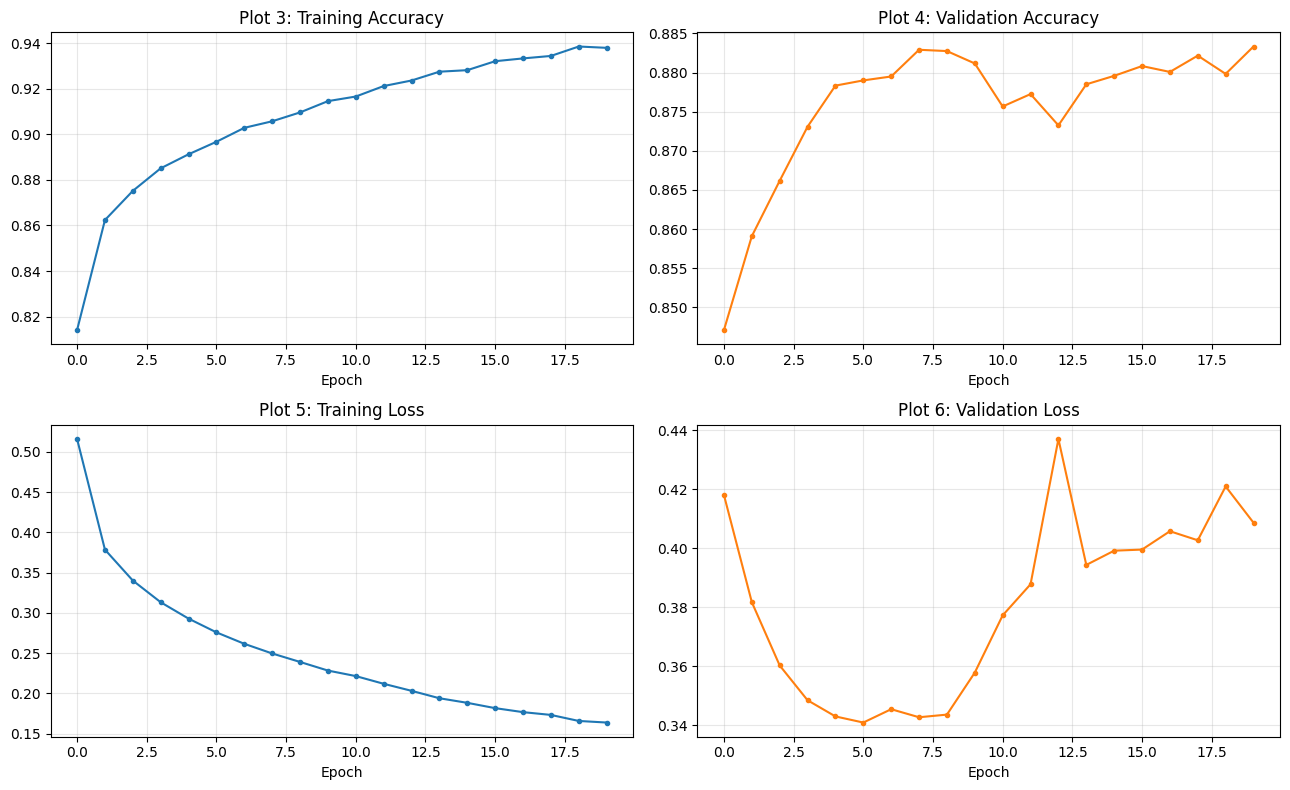

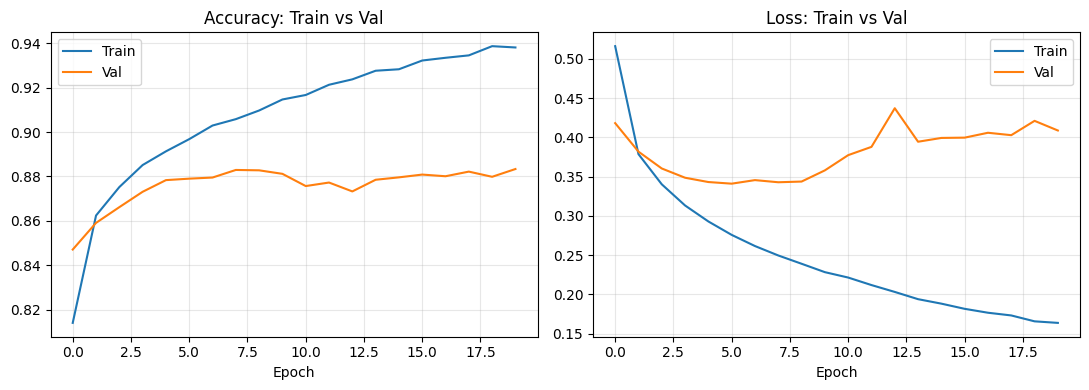

In [ ]:
h = history.history
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
specs = [(0,0,'accuracy',"Plot 3: Training Accuracy",'tab:blue'),
         (0,1,'val_accuracy',"Plot 4: Validation Accuracy",'tab:orange'),
         (1,0,'loss',"Plot 5: Training Loss",'tab:blue'),
         (1,1,'val_loss',"Plot 6: Validation Loss",'tab:orange')]
for r,c,k,t,col in specs:
    ax[r,c].plot(h[k], color=col, marker='o', ms=3)
    ax[r,c].set_title(t); ax[r,c].set_xlabel("Epoch"); ax[r,c].grid(alpha=.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(h['accuracy'], label='Train'); plt.plot(h['val_accuracy'], label='Val')
plt.title("Accuracy: Train vs Val"); plt.xlabel("Epoch"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1,2,2)
plt.plot(h['loss'], label='Train'); plt.plot(h['val_loss'], label='Val')
plt.title("Loss: Train vs Val"); plt.xlabel("Epoch"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
y_pred_base = np.argmax(baseline.predict(X_test_norm, verbose=0), axis=1)

base_acc  = accuracy_score(y_test, y_pred_base)
base_prec = precision_score(y_test, y_pred_base, average='macro')
base_rec  = recall_score(y_test, y_pred_base, average='macro')
base_f1   = f1_score(y_test, y_pred_base, average='macro')

print(f"Accuracy : {base_acc:.4f}\nPrecision: {base_prec:.4f}")
print(f"Recall   : {base_rec:.4f}\nF1-score : {base_f1:.4f}\n")
print(classification_report(y_test, y_pred_base, target_names=class_names, digits=3))

Accuracy : 0.8784
Precision: 0.8817
Recall   : 0.8784
F1-score : 0.8788

              precision    recall  f1-score   support

 T-shirt/top      0.871     0.754     0.808      1000
     Trouser      0.986     0.971     0.978      1000
    Pullover      0.807     0.791     0.799      1000
       Dress      0.906     0.871     0.888      1000
        Coat      0.732     0.870     0.795      1000
      Sandal      0.983     0.951     0.967      1000
       Shirt      0.685     0.691     0.688      1000
     Sneaker      0.916     0.978     0.946      1000
         Bag      0.962     0.968     0.965      1000
  Ankle boot      0.969     0.939     0.954      1000

    accuracy                          0.878     10000
   macro avg      0.882     0.878     0.879     10000
weighted avg      0.882     0.878     0.879     10000



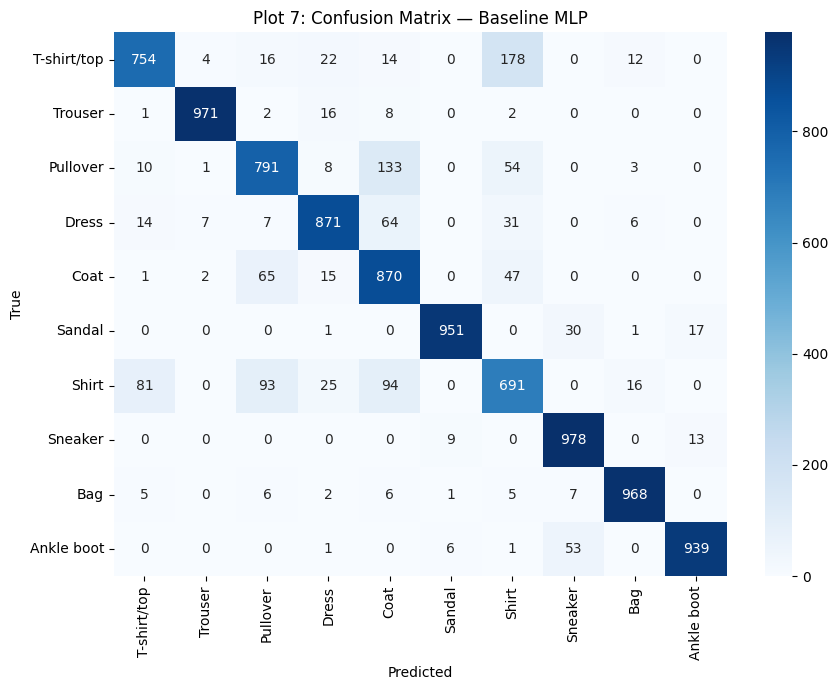

Largest confusion: 178 images of 'T-shirt/top' predicted as 'Shirt'


In [ ]:
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Plot 7: Confusion Matrix — Baseline MLP")
plt.tight_layout(); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"Largest confusion: {cm[i,j]} images of '{class_names[i]}' predicted as '{class_names[j]}'")

In [ ]:
def build_model(n_layers=2, n_neurons=128, activation='relu',
                dropout=0.0, optimizer_name='adam', learning_rate=0.001):
    m = tf.keras.Sequential([tf.keras.layers.Input(shape=(784,))])
    for _ in range(n_layers):
        m.add(tf.keras.layers.Dense(n_neurons, activation=activation))
        if dropout > 0: m.add(tf.keras.layers.Dropout(dropout))
    m.add(tf.keras.layers.Dense(10, activation='softmax'))
    opts = {'adam': tf.keras.optimizers.Adam, 'sgd': tf.keras.optimizers.SGD,
            'rmsprop': tf.keras.optimizers.RMSprop}
    m.compile(optimizer=opts[optimizer_name](learning_rate=learning_rate),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

clf = KerasClassifier(model=build_model, verbose=0)

param_dist = {
    'model__n_layers':      [1, 2, 3],
    'model__n_neurons':     [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer_name':['sgd', 'adam', 'rmsprop'],
    'model__activation':    ['relu', 'tanh', 'sigmoid'],
    'model__dropout':       [0.0, 0.2, 0.5],
    'batch_size':           [16, 32, 64, 128],
    'epochs':               [10, 20, 30],
}

# Subsample for tractability — 5-fold CV on 60k would take hours
SUB = 8000
idx = np.random.RandomState(42).choice(len(X_train_norm), SUB, replace=False)
X_sub, y_sub = X_train_norm[idx], y_train[idx]
print("Search subset:", X_sub.shape)

Search subset: (8000, 784)


In [ ]:
search = RandomizedSearchCV(clf, param_dist, n_iter=10, cv=5,
                            scoring='accuracy', n_jobs=1, verbose=2,
                            random_state=42, refit=False)
t0 = time.time()
search.fit(X_sub, y_sub)
print(f"\nSearch time: {(time.time()-t0)/60:.1f} min")
print("Best CV accuracy:", round(search.best_score_, 4))
for k, v in search.best_params_.items(): print(f"  {k}: {v}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__learning_rate=0.1, model__n_layers=3, model__n_neurons=256, model__optimizer_name=adam; total time=  11.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__learning_rate=0.1, model__n_layers=3, model__n_neurons=256, model__optimizer_name=adam; total time=  11.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__learning_rate=0.1, model__n_layers=3, model__n_neurons=256, model__optimizer_name=adam; total time=  10.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__learning_rate=0.1, model__n_layers=3, model__n_neurons=256, model__optimizer_name=adam; total time=  10.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__learning_rate=0.1, model__n_layers=3, model__n_neurons=256, model__optimizer_name

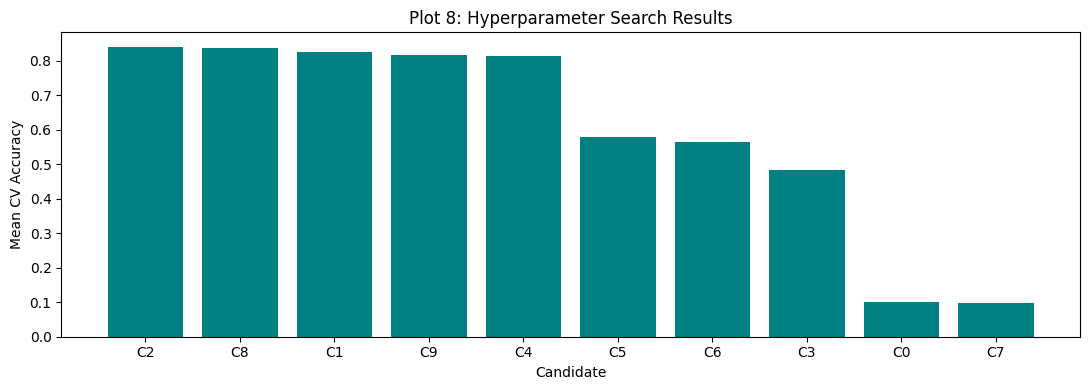

Impact of each hyperparameter (spread of mean CV accuracy):
  model__n_layers          spread = 0.2704
  model__n_neurons         spread = 0.3262
  model__learning_rate     spread = 0.4690
  model__optimizer_name    spread = 0.2967
  model__activation        spread = 0.2072
  model__dropout           spread = 0.1521
  batch_size               spread = 0.4805
  epochs                   spread = 0.2378


In [ ]:
import pandas as pd
res = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(11,4))
plt.bar(range(len(res)), res['mean_test_score'], color='teal')
plt.xticks(range(len(res)), [f"C{i}" for i in res.index], rotation=0)
plt.ylabel("Mean CV Accuracy"); plt.xlabel("Candidate")
plt.title("Plot 8: Hyperparameter Search Results")
plt.tight_layout(); plt.show()

print("Impact of each hyperparameter (spread of mean CV accuracy):")
for p in param_dist:
    g = res.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"  {p:<24} spread = {g.max()-g.min():.4f}")

In [ ]:
bp = search.best_params_
opt_model = build_model(n_layers=bp['model__n_layers'], n_neurons=bp['model__n_neurons'],
                        activation=bp['model__activation'], dropout=bp['model__dropout'],
                        optimizer_name=bp['model__optimizer_name'],
                        learning_rate=bp['model__learning_rate'])
opt_model.summary()

t0 = time.time()
hist_opt = opt_model.fit(X_train_norm, y_train, epochs=bp['epochs'],
                         batch_size=bp['batch_size'], validation_split=0.2, verbose=1)
opt_time = time.time() - t0
print(f"\nOptimized training time: {opt_time:.1f}s")

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_168 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,562 (107.66 KB)

 Trainable params: 27,562 (107.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7477 - loss: 0.7141 - val_accuracy: 0.8374 - val_loss: 0.4597
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8158 - loss: 0.5347 - val_accuracy: 0.8443 - val_loss: 0.4398
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8292 - loss: 0.4927 - val_accuracy: 0.8510 - val_loss: 0.4256
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8371 - loss: 0.4741 - val_accuracy: 0.8566 - val_loss: 0.4072
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8438 - loss: 0.4589 - val_accuracy: 0.8583 - val_loss: 0.3998
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8446 - loss: 0.4517 - val_accuracy: 0.8612 - val_loss: 0.4037
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8492 - loss: 0.4434 - val_accuracy: 0.8605 - val_loss: 0.3957
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8520 - loss: 0.4307 

              precision    recall  f1-score   support

 T-shirt/top      0.841     0.772     0.805      1000
     Trouser      0.992     0.954     0.972      1000
    Pullover      0.766     0.768     0.767      1000
       Dress      0.848     0.874     0.861      1000
        Coat      0.768     0.796     0.782      1000
      Sandal      0.956     0.941     0.949      1000
       Shirt      0.641     0.676     0.658      1000
     Sneaker      0.894     0.959     0.925      1000
         Bag      0.964     0.959     0.961      1000
  Ankle boot      0.970     0.916     0.942      1000

    accuracy                          0.862     10000
   macro avg      0.864     0.862     0.862     10000
weighted avg      0.864     0.862     0.862     10000

           Metric   Baseline  Optimized
         Accuracy   0.878400   0.861500
        Precision   0.881694   0.863999
           Recall   0.878400   0.861500
         F1-score   0.878827   0.862275
Training Time (s) 132.300000 185.200000


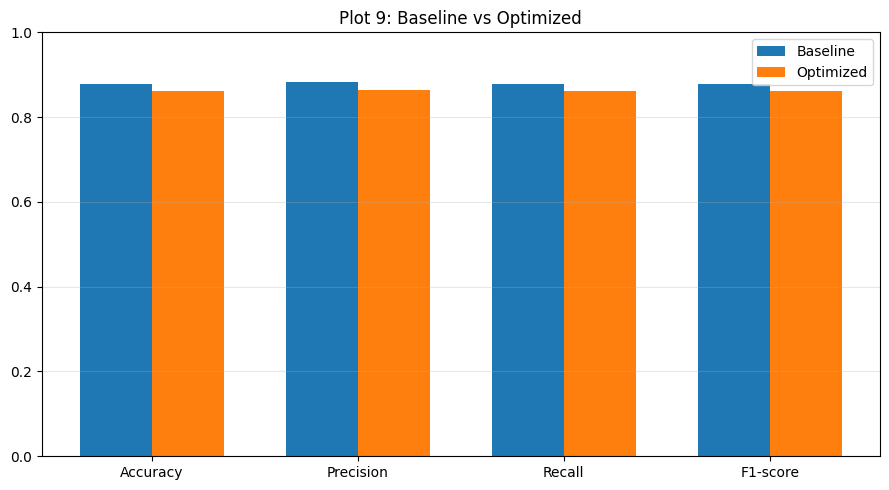

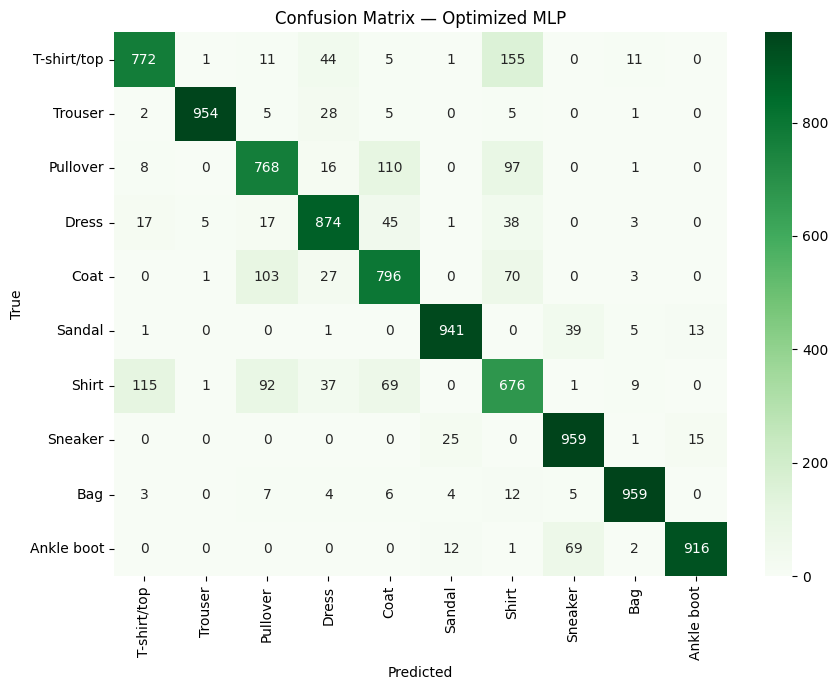

In [ ]:
y_pred_opt = np.argmax(opt_model.predict(X_test_norm, verbose=0), axis=1)
opt_acc  = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='macro')
opt_rec  = recall_score(y_test, y_pred_opt, average='macro')
opt_f1   = f1_score(y_test, y_pred_opt, average='macro')

print(classification_report(y_test, y_pred_opt, target_names=class_names, digits=3))

comp = pd.DataFrame({
    'Metric':   ['Accuracy','Precision','Recall','F1-score','Training Time (s)'],
    'Baseline': [base_acc, base_prec, base_rec, base_f1, round(baseline_time,1)],
    'Optimized':[opt_acc,  opt_prec,  opt_rec,  opt_f1,  round(opt_time,1)]})
print(comp.to_string(index=False))

m = ['Accuracy','Precision','Recall','F1-score']
x = np.arange(4); w = 0.35
plt.figure(figsize=(9,5))
plt.bar(x-w/2, [base_acc,base_prec,base_rec,base_f1], w, label='Baseline')
plt.bar(x+w/2, [opt_acc,opt_prec,opt_rec,opt_f1],   w, label='Optimized')
plt.xticks(x, m); plt.ylim(0,1); plt.legend(); plt.grid(axis='y', alpha=.3)

plt.title("Plot 9: Baseline vs Optimized")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,7))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Optimized MLP")
plt.tight_layout(); plt.show()